Total key bits: 492
Errors: 132
Error rate: 26.83 %


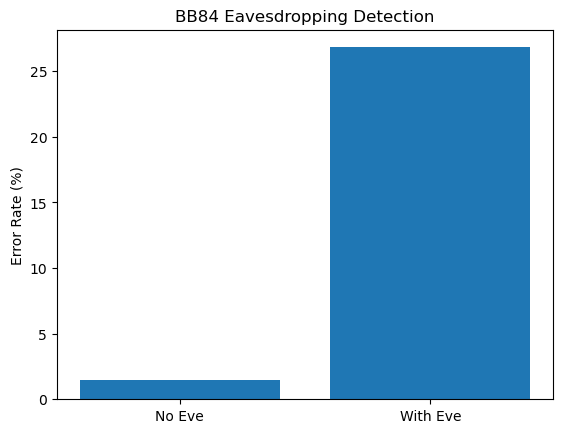

In [3]:
import random
import matplotlib.pyplot as plt

# PARAMETERS
# simulating 1000 quantum transmissions
# each “bit” represents one qubit sent from Alice to Bob
N = 1000  # number of bits


# generating a classical random bit, 0 or 1, with equal probability
def random_bit():
    return random.randint(0, 1)


# generating a random measurement/encoding basis:
# 0 = '+' basis (rectilinear/standard encoding)
# 1 = '×' basis (diagonal/rotated encoding)
def random_basis():
    return random.randint(0, 1)


# STEP 1: ALICE GENERATES DATA
# creating Alice’s “quantum message”
# for each of the 1000 positions we have

# a list of random 0s and 1s
# this is the secret information Alice wants to send (the raw data before encryption)
alice_bits = [random_bit() for _ in range(N)]

# a list of random 0s and 1s
# each value decides how the bit is encoded
alice_bases = [random_basis() for _ in range(N)]

# STEP 2: INTRODUCING EVE (optional attacker)
# flag for the attacker's existence
# True - simulate attack
# False - secure communication
EVE_PRESENT = True

intermediate_bits = []

# we process each transmitted bit one by one
for i in range(N):
    if EVE_PRESENT:
        # Eve intercepts the bits from Alice
        # Eve randomly chooses a basis to measure the qubit
        # she does not know Alice’s basis, so she guesses
        eve_basis = random_basis()

        # if Eve guesses correctly, she has the same basis as Alice, which means she gets the correct bit
        # otherwise, the measurement destroys the original info and the output becomes random
        if eve_basis == alice_bases[i]:
            bit = alice_bits[i]
        else:
            bit = random_bit()

    # if there is no attacker, data passes untouched
    else:
        bit = alice_bits[i]

    # store the result (the channel output)
    intermediate_bits.append(bit)

# STEP 3: BOB MEASURES
bob_bits = []

# Bob also randomly chooses a basis for each incoming signal
# just like Eve, Bob does not know how the bits were encoded; he must guess the measurement basis
bob_bases = [random_basis() for _ in range(N)]

# we process each quantum signal one by one
for i in range(N):
    if bob_bases[i] == alice_bases[i]:
        # if Bob happened to guess the same basis Alice used
        # measurement is compatible, he can recover the correct bit (or disturbed version)
        # he does not get Alice’s original bit directly, he gets whatever survived Eve’s interference
        # no Eve - correct bit
        # Eve present - possibly corrupted bit
        bob_bits.append(intermediate_bits[i])
    else:
        # wrong basis - the result is completely random due to quantum uncertainty
        bob_bits.append(random_bit())

# STEP 4: KEY SIFTING
final_alice = []  # Alice’s version of the key
final_bob = []  # Bob’s version of the key

# we go through all transmitted bits again, but this time we are filtering results, not transmitting data
# essentially, we are only keeping the bits for which Bob correctly guessed the basis Alice used
# however, even though bases match, Bob’s bit may still be wrong if Eve interfered earlier
# so matching bases doesn't guarantee correctness when attacker exists
for i in range(N):
    if alice_bases[i] == bob_bases[i]:
        final_alice.append(alice_bits[i])
        final_bob.append(bob_bits[i])

# STEP 5: ERROR RATE
errors = 0
# Alice and Bob compare their final shared key bits
# even after sifting, mismatches exist because Eve disturbed the quantum state, so Bob receives corrupted data
for a, b in zip(final_alice, final_bob):
    if a != b:
        errors += 1

error_rate = errors / len(final_alice) if final_alice else 0  # percentage of corruption

# OUTPUT
print("Total key bits:", len(final_alice))
print("Errors:", errors)
print("Error rate:", round(error_rate * 100, 2), "%")

labels = ["No Eve", "With Eve"]
values = [1.5, error_rate * 100]

plt.bar(labels, values)
plt.ylabel("Error Rate (%)")
plt.title("BB84 Eavesdropping Detection")
plt.show()